In [8]:
from collections import defaultdict
import os
from typing import List

import numpy as np
from llmcal.utils import load_yaml
from datasets import load_from_disk
from scipy.special import log_softmax
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt



In [17]:


def _compute_metric(logits, targets, metric):
    if metric == "accuracy":
        return accuracy_score(targets, logits.argmax(axis=1))
    elif metric == "error_rate":
        return 1 - accuracy_score(targets, logits.argmax(axis=1))
    elif metric == "norm_cross_entropy":
        naive_priors = np.bincount(targets, minlength=logits.shape[1]) / len(targets)
        naive_entropy = - np.mean(np.log(naive_priors[targets]))
        logprobs = log_softmax(logits, axis=1)
        cross_entropy = - np.mean(logprobs[np.arange(len(targets)), targets])
        return cross_entropy / naive_entropy
    else:
        raise ValueError(f"Metric {metric} is not supported")


def compute_metric(logits, targets, metric, bootstrap, random_state):
    if bootstrap == 0:
        return [_compute_metric(logits, targets, metric)]
    
    rs = np.random.RandomState(random_state)
    values = []
    for _ in range(bootstrap):
        idx = rs.choice(len(targets), len(targets), replace=True)
        values.append(_compute_metric(logits[idx], targets[idx], metric))
    return values

def main(
    *methods,
    metrics: List[str] = ["error_rate", "norm_cross_entropy"],
    bootstrap: int = 100,
    random_state: int = 0,
    split: str = "test", 
):
    experiments_dir = f"../experiments"
    all_results = defaultdict(list)
    for task in os.listdir(experiments_dir):
        for model in os.listdir(os.path.join(experiments_dir,task)):
            method = os.path.join(task, model)
            if method not in methods:
                continue
            for fold in os.listdir(os.path.join(experiments_dir,task,model)):
                config = load_yaml(os.path.join(experiments_dir, task, model, fold, "config.yaml"))
                results = load_from_disk(os.path.join(experiments_dir, task, model, fold, split)).flatten().select_columns(["output.logits", "target"]).with_format("numpy")
                logits = results["output.logits"]
                targets = results["target"]
                for metric in metrics:
                    value = compute_metric(logits, targets, metric, bootstrap, random_state)
                    all_results["value"].extend(value)
                    all_results["metric"].extend([metric]*len(value))
                    all_results["method"].extend([method]*len(value))
                    all_results["n_samples"].extend([config["splits"]["train_samples"]]*len(value))
                    all_results["fold"].extend([fold]*len(value))
    df = pd.DataFrame(all_results)
    df = df.groupby(["method", "metric", "n_samples"]).agg({"value": ["mean", "std"]}).reset_index()


    return df

from collections import OrderedDict
METHODS = OrderedDict([
    ("glue_sst2_inst_0-shot-AB_tinyllama-logits/no_adapt", {"name": "No adaptation", "color": "C0", "linestyle": "-", "marker": "o", "markersize": 5, "linewidth": 1, "alpha": 1}),
    ("glue_sst2_inst_0-shot-AB_tinyllama-logits/affine_vector", {"name": "Affine vector", "color": "C1", "linestyle": "-", "marker": "o", "markersize": 5, "linewidth": 1, "alpha": 1}),
])

metrics = ["accuracy", "norm_cross_entropy"]
df = main(
    "glue_sst2_inst_0-shot-AB_tinyllama-logits/no_adapt",
    "glue_sst2_inst_0-shot-AB_tinyllama-logits/affine_vector",
    metrics=metrics,
    bootstrap=100,
    random_state=123
)
df

method              metric  \
                                                                           
0  glue_sst2_inst_0-shot-AB_tinyllama-logits/affi...            accuracy   
1  glue_sst2_inst_0-shot-AB_tinyllama-logits/affi...            accuracy   
2  glue_sst2_inst_0-shot-AB_tinyllama-logits/affi...  norm_cross_entropy   
3  glue_sst2_inst_0-shot-AB_tinyllama-logits/affi...  norm_cross_entropy   
4  glue_sst2_inst_0-shot-AB_tinyllama-logits/no_a...            accuracy   
5  glue_sst2_inst_0-shot-AB_tinyllama-logits/no_a...            accuracy   
6  glue_sst2_inst_0-shot-AB_tinyllama-logits/no_a...  norm_cross_entropy   
7  glue_sst2_inst_0-shot-AB_tinyllama-logits/no_a...  norm_cross_entropy   

  n_samples     value            
                 mean       std  
0         8  0.510619  0.017114  
1       100  0.580250  0.032871  
2         8  1.197442  0.027168  
3       100  1.013716  0.051362  
4         8  0.470700  0.016947  
5       100  0.449600  0.031692  
6         8  1.065746  0.010264  
7       100  1.084670  0.022978

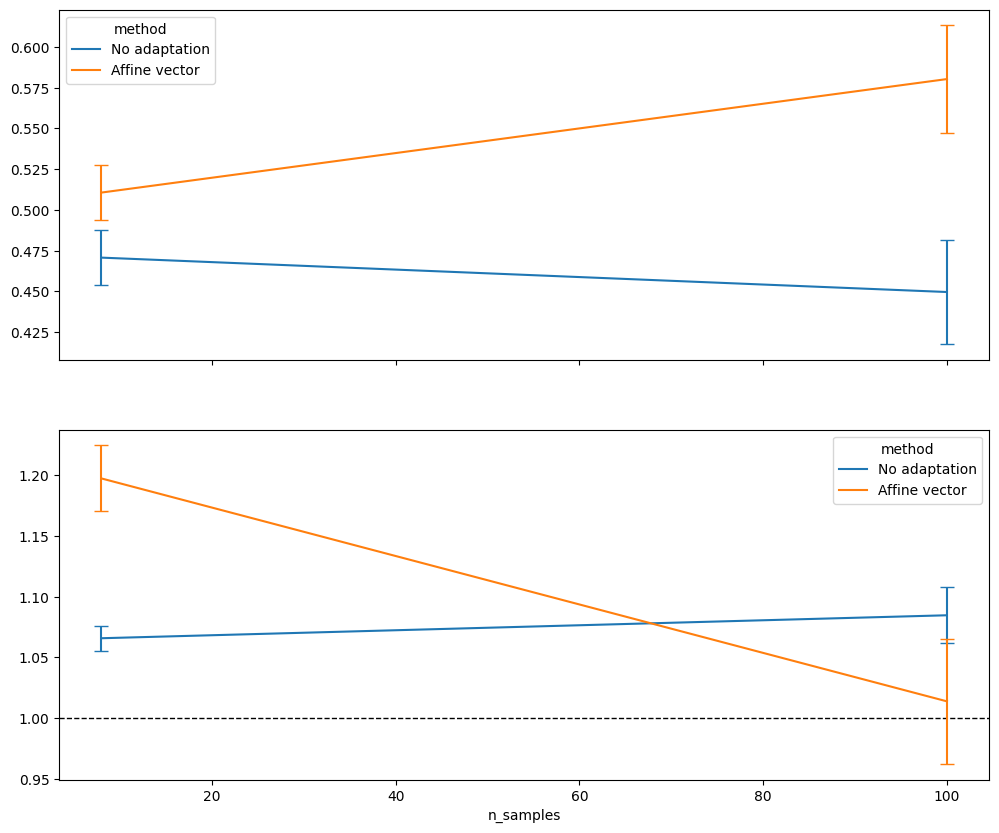

In [20]:
metrics = ["accuracy", "norm_cross_entropy"]
num_samples = df["n_samples"].unique()
fig, ax = plt.subplots(len(metrics), 1, figsize=(len(num_samples) * 6, len(metrics) * 5), sharex=True)
if len(metrics) == 1:
    ax = np.array([ax])

for i, metric in enumerate(metrics):
    if metric == "norm_cross_entropy":
        ax[i].axhline(1, color="black", linestyle="--", linewidth=1)
    dfp = df[df["metric"] == metric].pivot(index="n_samples", columns="method", values=("value", "mean"))
    dfp = dfp.rename(columns=lambda x: METHODS[x]["name"])
    dfp = dfp.reindex([v["name"] for k, v in METHODS.items()], axis=1)
    yerr = df[df["metric"] == metric].pivot(index="n_samples", columns="method", values=("value", "std"))
    yerr = yerr.rename(columns=lambda x: METHODS[x]["name"])
    yerr = yerr.reindex([v["name"] for k, v in METHODS.items()], axis=1)
    dfp.plot(kind="line", ax=ax[i], yerr=yerr, capsize=5, legend=False)

reindex_rows = {}
for n in dfp.index:
    reindex_rows[n] = f"{n} samples\n"
ax[-1].set_xticks(range(len(num_samples)))
ax[-1].set_xticklabels([reindex_rows[n] for n in num_samples], fontsize=15)
ax[-1].set_xlabel("Number of Samples", fontsize=15)
ax[-1].legend(fontsize=15, bbox_to_anchor=(0.5,-0.8), ncol=6, loc="lower center")
ax[0].set_title(f"{SUPPORTED_MODELS[model]} on {SUPPORTED_DATASETS[dataset]['name']}", fontsize=20)
fig.tight_layout()
    

In [11]:
df.index

RangeIndex(start=0, stop=8, step=1)